In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.5 MB/s eta 0:00:00


In [4]:
from ultralytics import RTDETR

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"
ZIP_PATH = f"{PROJECT_DIR}/dataset/WilderPerson.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/WilderPerson.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [6]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/WilderPerson.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [6]:
!ls /content/final-year-research/dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [7]:
!find /content/final-year-research -maxdepth 3 -type d

/content/final-year-research
/content/final-year-research/dataset
/content/final-year-research/dataset/train
/content/final-year-research/dataset/train/labels
/content/final-year-research/dataset/train/images
/content/final-year-research/dataset/valid
/content/final-year-research/dataset/valid/labels
/content/final-year-research/dataset/valid/images


In [8]:
import glob

ROOT = "/content/final-year-research/dataset"

print("train images:", len(glob.glob(ROOT + "/train/images/*")))
print("train labels:", len(glob.glob(ROOT + "/train/labels/*")))
print("valid images:", len(glob.glob(ROOT + "/valid/images/*")))
print("valid labels:", len(glob.glob(ROOT + "/valid/labels/*")))

train images: 10098
train labels: 10098
valid images: 3284
valid labels: 3284


In [9]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU name: NVIDIA A100-SXM4-40GB


In [14]:
import yaml

yaml_path = "/content/final-year-research/WilderPerson_colab.yaml"

data = {
    "path": "/content/final-year-research/dataset",
    "train": "/content/final-year-research/dataset/train/images",
    "val": "/content/final-year-research/dataset/valid/images",
    "names": {
        0: "pedestrian",
        1: "other"
    }
}

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("YAML fixed! Now defining 2 classes (0 and 1).")

YAML fixed! Now defining 2 classes (0 and 1).


In [9]:
model = RTDETR("rtdetr-l.pt")

In [ ]:
model.train(
    data="/content/final-year-research/WilderPerson_colab.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/final-year-research/runs",
    name="rtdetr_wilderperson_research_v1"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/WilderPerson_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_wilderperson_research_v1-5, nbs=64, nms=False, opset=None, op

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30        34G      0.673     0.4111     0.1245        127        640: 100% ━━━━━━━━━━━━ 632/632 2.1it/s 5:05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 3.5it/s 29.5s
                   all       3284     155080      0.878      0.818      0.891      0.549

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/30      16.3G     0.6393     0.4037     0.1336       1421        640: 0% ──────────── 0/632  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      31.5G     0.6038     0.4195     0.1059        200        640: 100% ━━━━━━━━━━━━ 632/632 2.3it/s 4:39
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 4.2it/s 24.4s
                   all       3284     155080      0.884      0.838      0.904      0.561

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/30        14G     0.5285     0.4185    0.09729        902        640: 0% ──────────── 0/632  0.5s

...

      12/30      31.2G     0.5051     0.4138    0.08126        269        640: 100% ━━━━━━━━━━━━ 632/632 2.3it/s 4:32
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 4.1it/s 24.9s
                   all       3284     155080      0.898      0.859       0.93      0.614

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      13/30      14.7G      0.494      0.428    0.07505       1008        640: 0% ──────────── 0/632  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      13/30      23.9G     0.4935     0.4111    0.07828        144        640: 100% ━━━━━━━━━━━━ 632/632 2.3it/s 4:32
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 4.1it/s 25.4s
                   all       3284     155080        0.9      0.866      0.936      0.632

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      14/30      13.5G     0.4909     0.4409    0.08854        841        640: 0% ──────────── 0/632  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      14/30      18.8G     0.5118     0.4114    0.08608       1402        640: 6% ╸─────────── 41/632 2.2it/s 18.6s<4:30

In [11]:
import os

path = "/content/drive/MyDrive/final-year-research/runs/rtdetr_wilderperson_research_v1-5/weights/last.pt"

print(os.path.exists(path))

True


In [15]:
from ultralytics import RTDETR

model = RTDETR("/content/drive/MyDrive/final-year-research/runs/rtdetr_wilderperson_research_v1-5/weights/last.pt")

model.train(
    data="/content/final-year-research/WilderPerson_colab.yaml",
    epochs=15,          # continue for 15 more epochs
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/final-year-research/runs",
    name="rtdetr_wilderperson_continue"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/WilderPerson_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/final-year-research/runs/rtdetr_wilderperson_research_v1-5/weights/last.pt, momentum=0.937, mosaic=1.0, mult

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/15      33.8G     0.4792     0.4082     0.0754        127        640: 100% ━━━━━━━━━━━━ 632/632 2.1it/s 5:03
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 3.4it/s 30.4s
                   all       3284     155080      0.904      0.868      0.936      0.631

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/15      15.7G     0.5028     0.3985    0.08639       1421        640: 0% ──────────── 0/632  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/15      30.9G     0.4845       0.41    0.07699        200        640: 100% ━━━━━━━━━━━━ 632/632 2.2it/s 4:48
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 4.1it/s 25.4s
                   all       3284     155080      0.901       0.87      0.935       0.62

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/15      13.3G     0.4197     0.4145    0.07153        902        640: 0% ──────────── 0/632  0.5s

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      14/15      26.7G     0.3845     0.3967    0.05972         60        640: 100% ━━━━━━━━━━━━ 632/632 2.5it/s 4:16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 4.1it/s 25.1s
                   all       3284     155080      0.904      0.874      0.941      0.643

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      15/15      12.6G     0.4145     0.4068    0.05748        655        640: 0% ──────────── 0/632  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      15/15      22.2G     0.3777     0.3941    0.05884         81        640: 100% ━━━━━━━━━━━━ 632/632 2.5it/s 4:15
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 4.1it/s 24.9s
                   all       3284     155080      0.908      0.875      0.943      0.644

15 epochs completed in 1.226 hours.
Optimizer stripped from /content/drive/MyDrive/final-year-research/runs/rtdetr_wilderperson_continue-2/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/final-year-research/runs/rtdetr_wilderperson_continue-2/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/final-year-research/runs/rtdetr_wilderperson_continue-2/weights/best.pt...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
rt-detr-l summary: 310 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-9

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f3f6a0879e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [1]:
RUN_DIR = "/content/drive/MyDrive/final-year-research/runs/rtdetr_wilderperson_continue-2"

Showing: BoxPR_curve.png


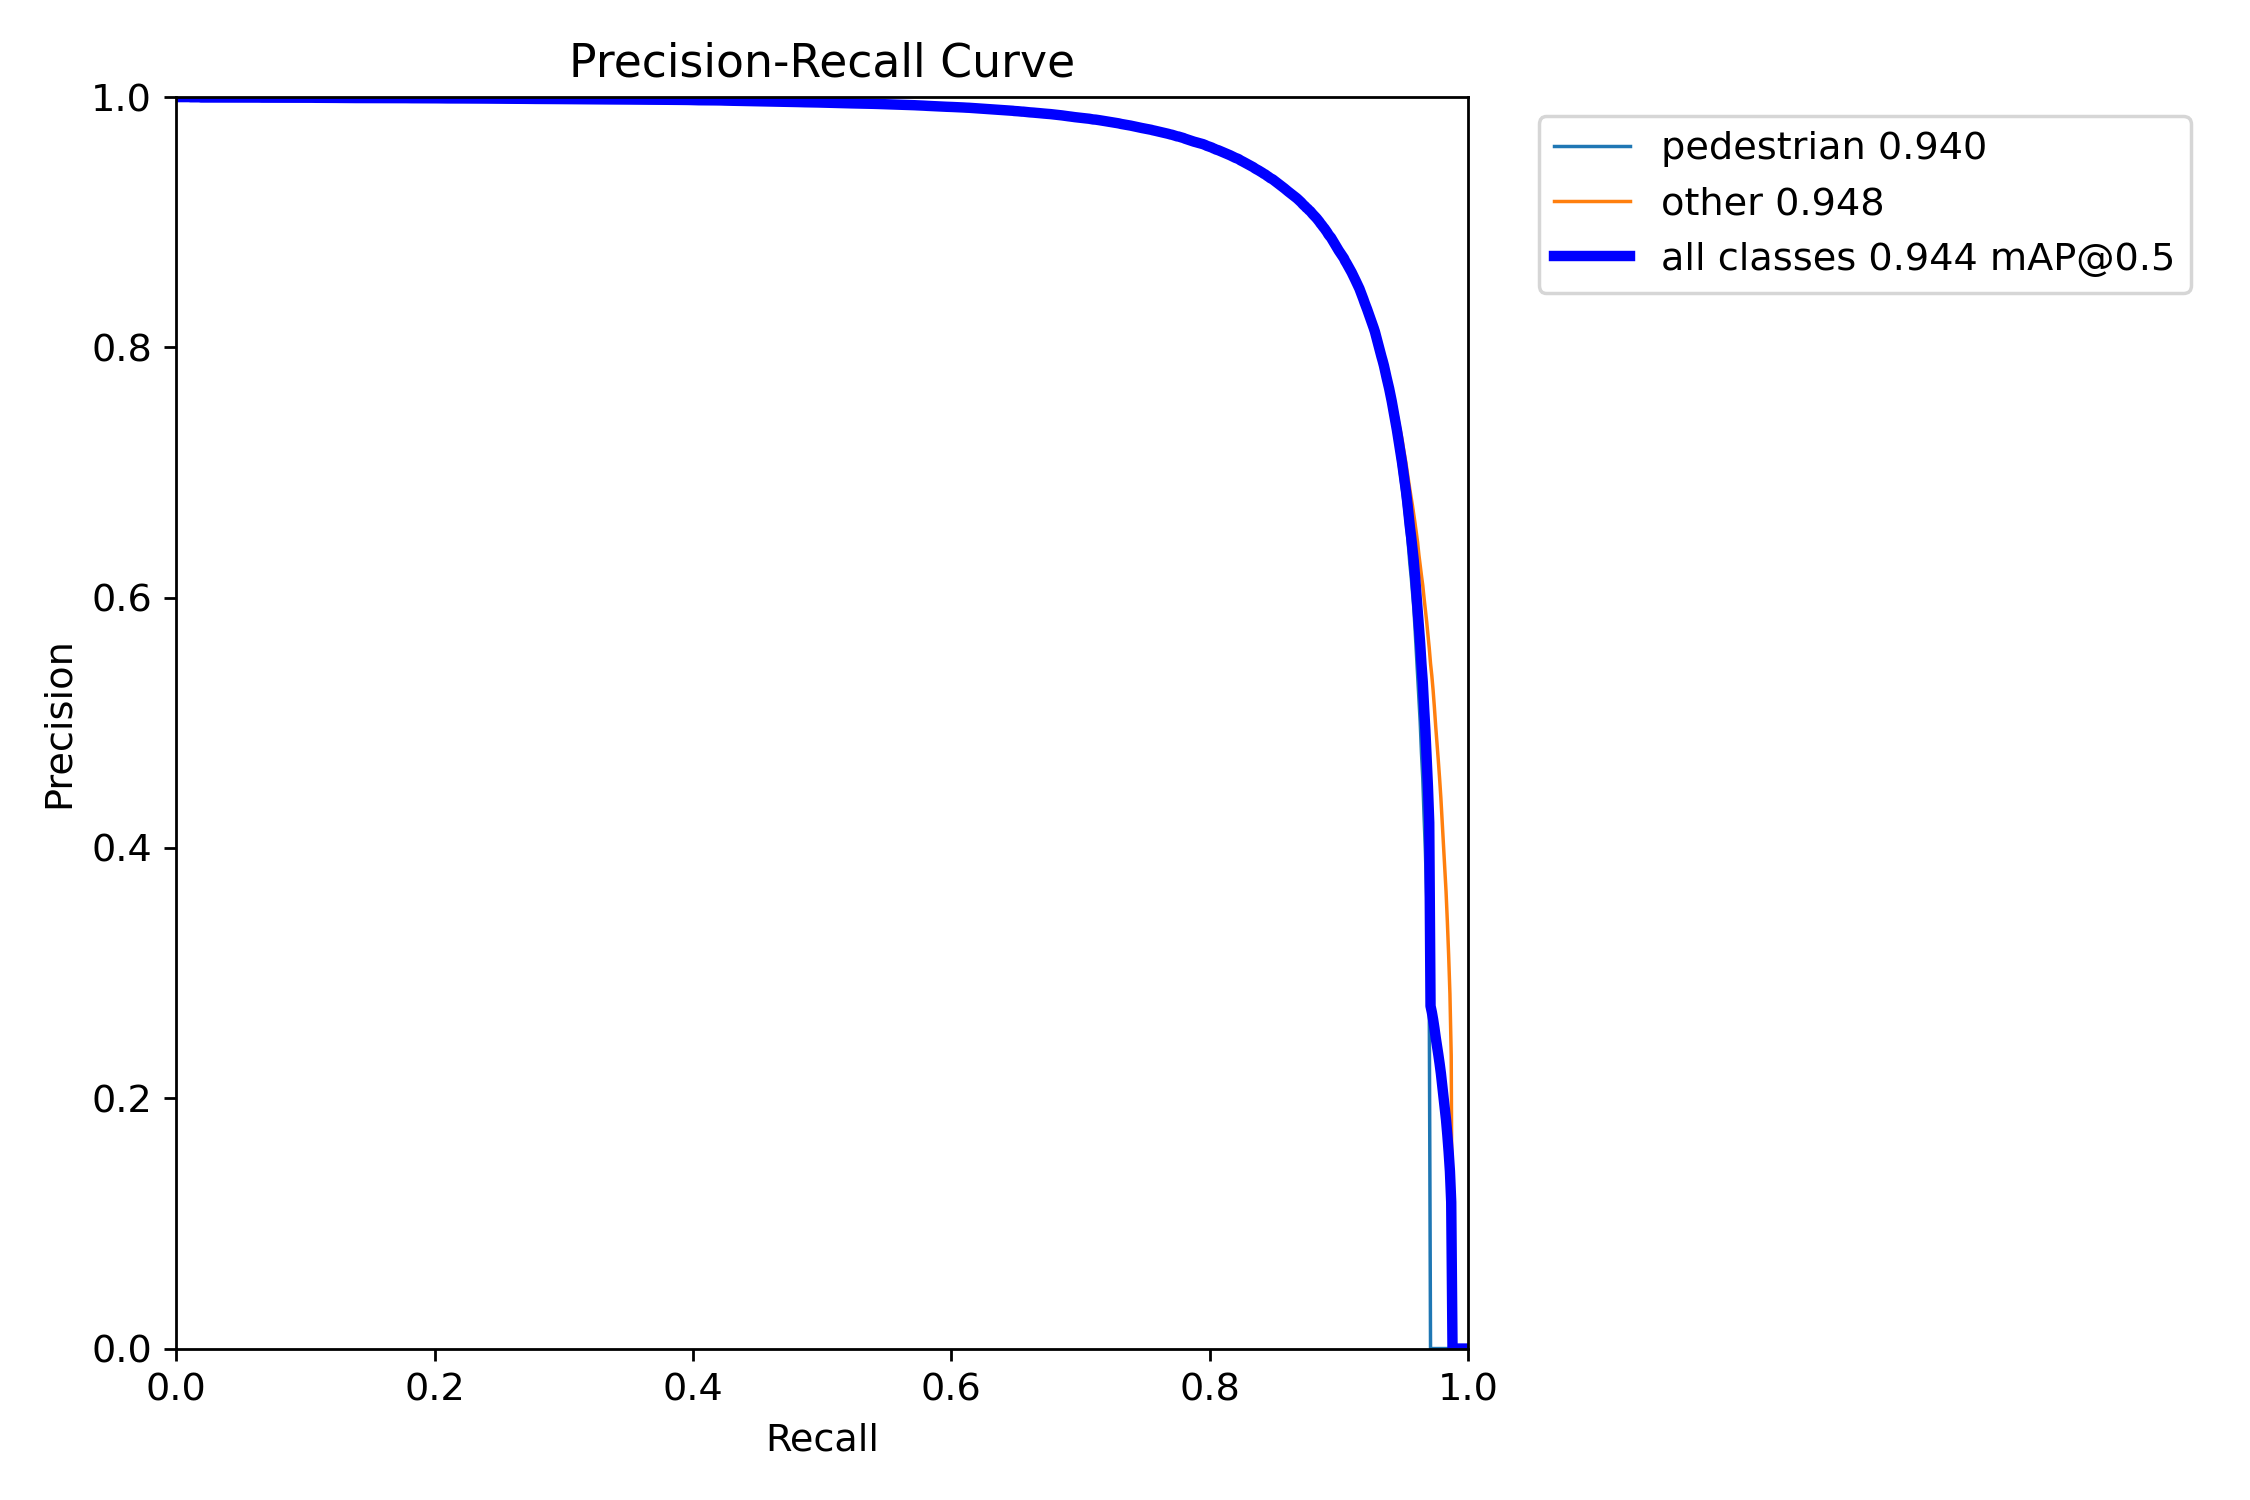

Showing: BoxF1_curve.png


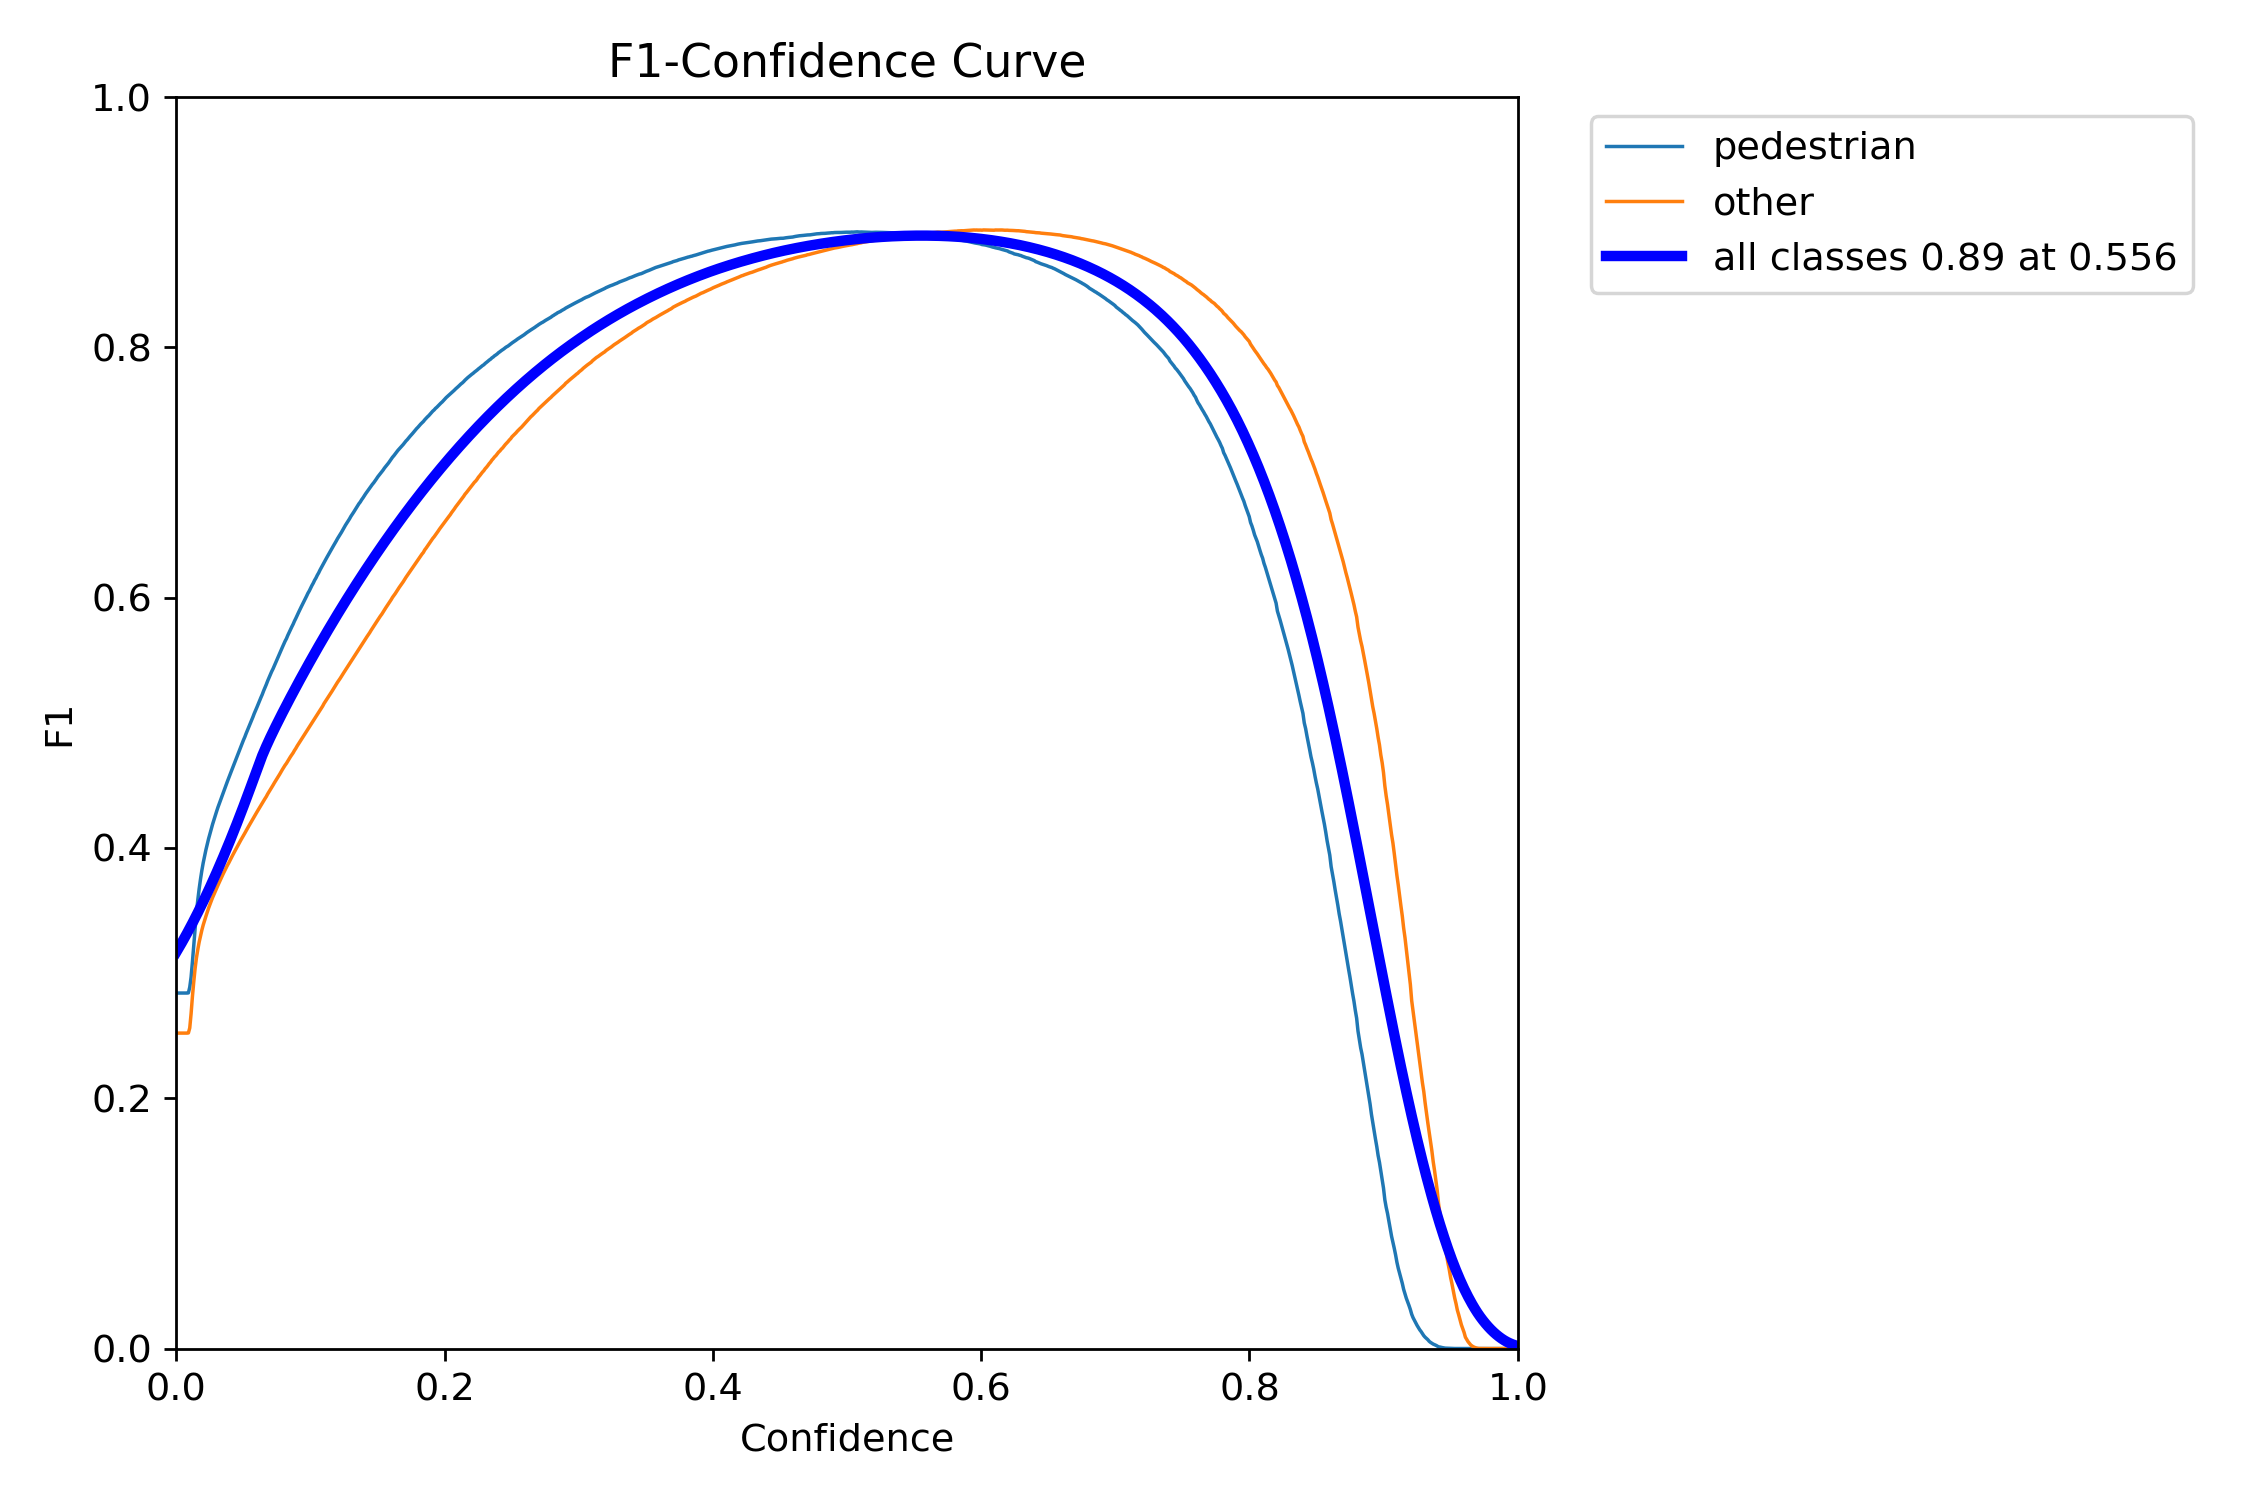

Showing: BoxP_curve.png


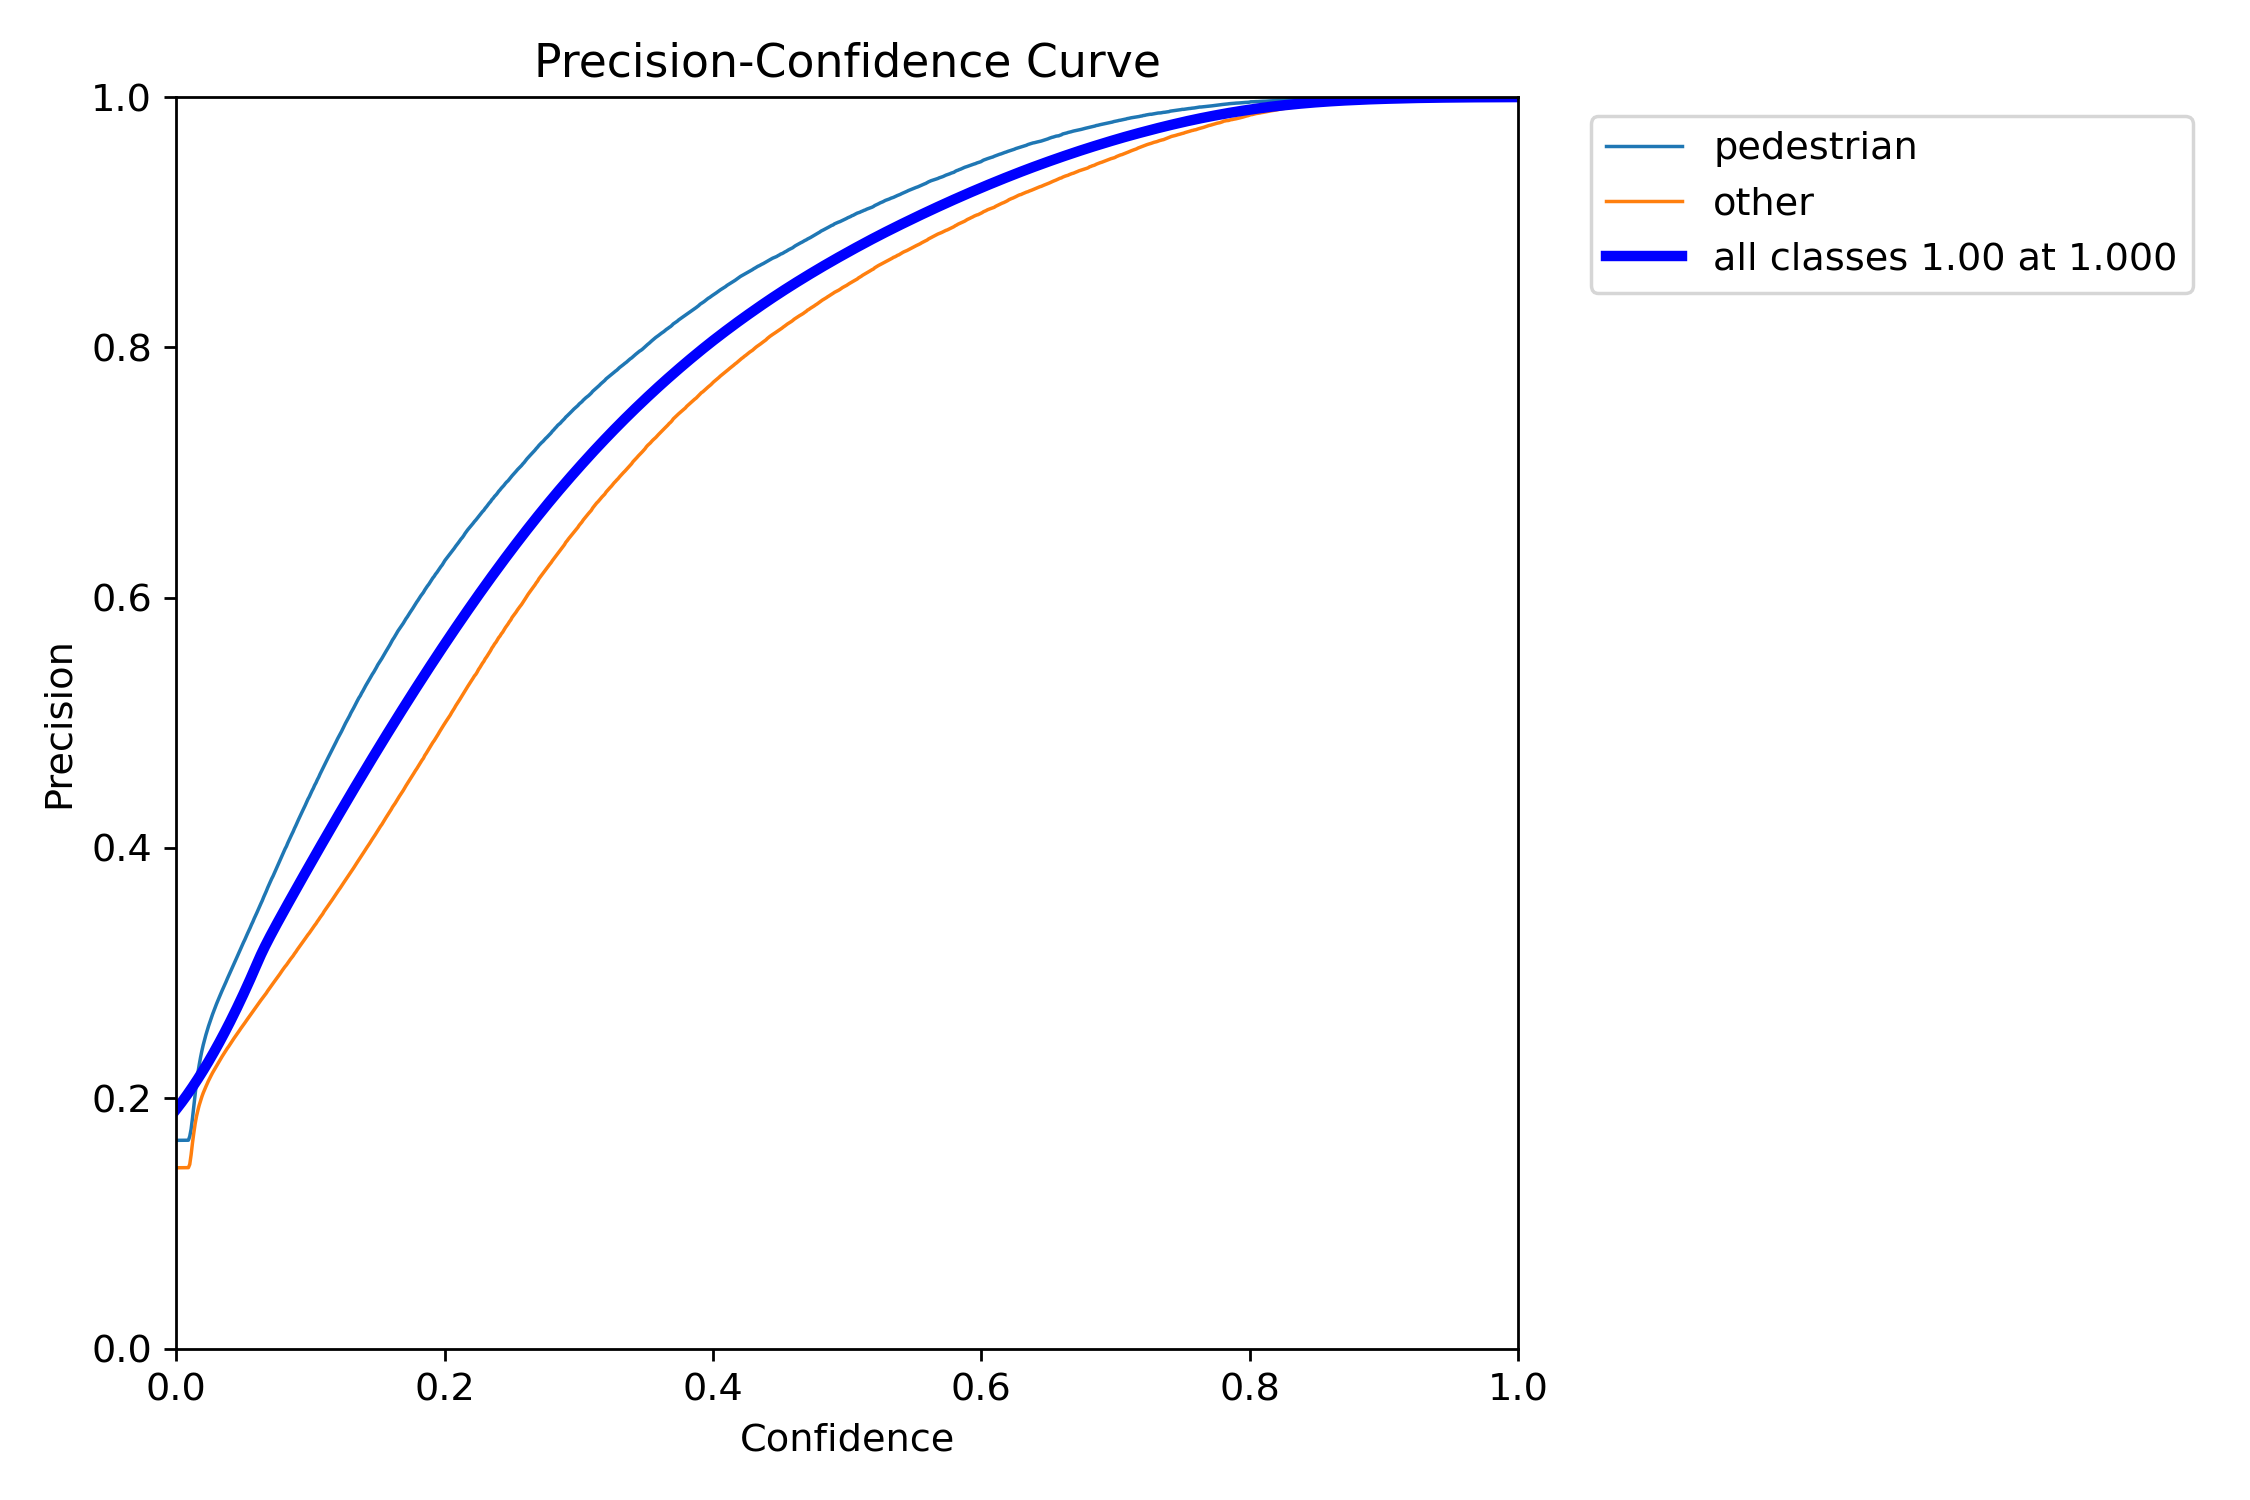

Showing: BoxR_curve.png


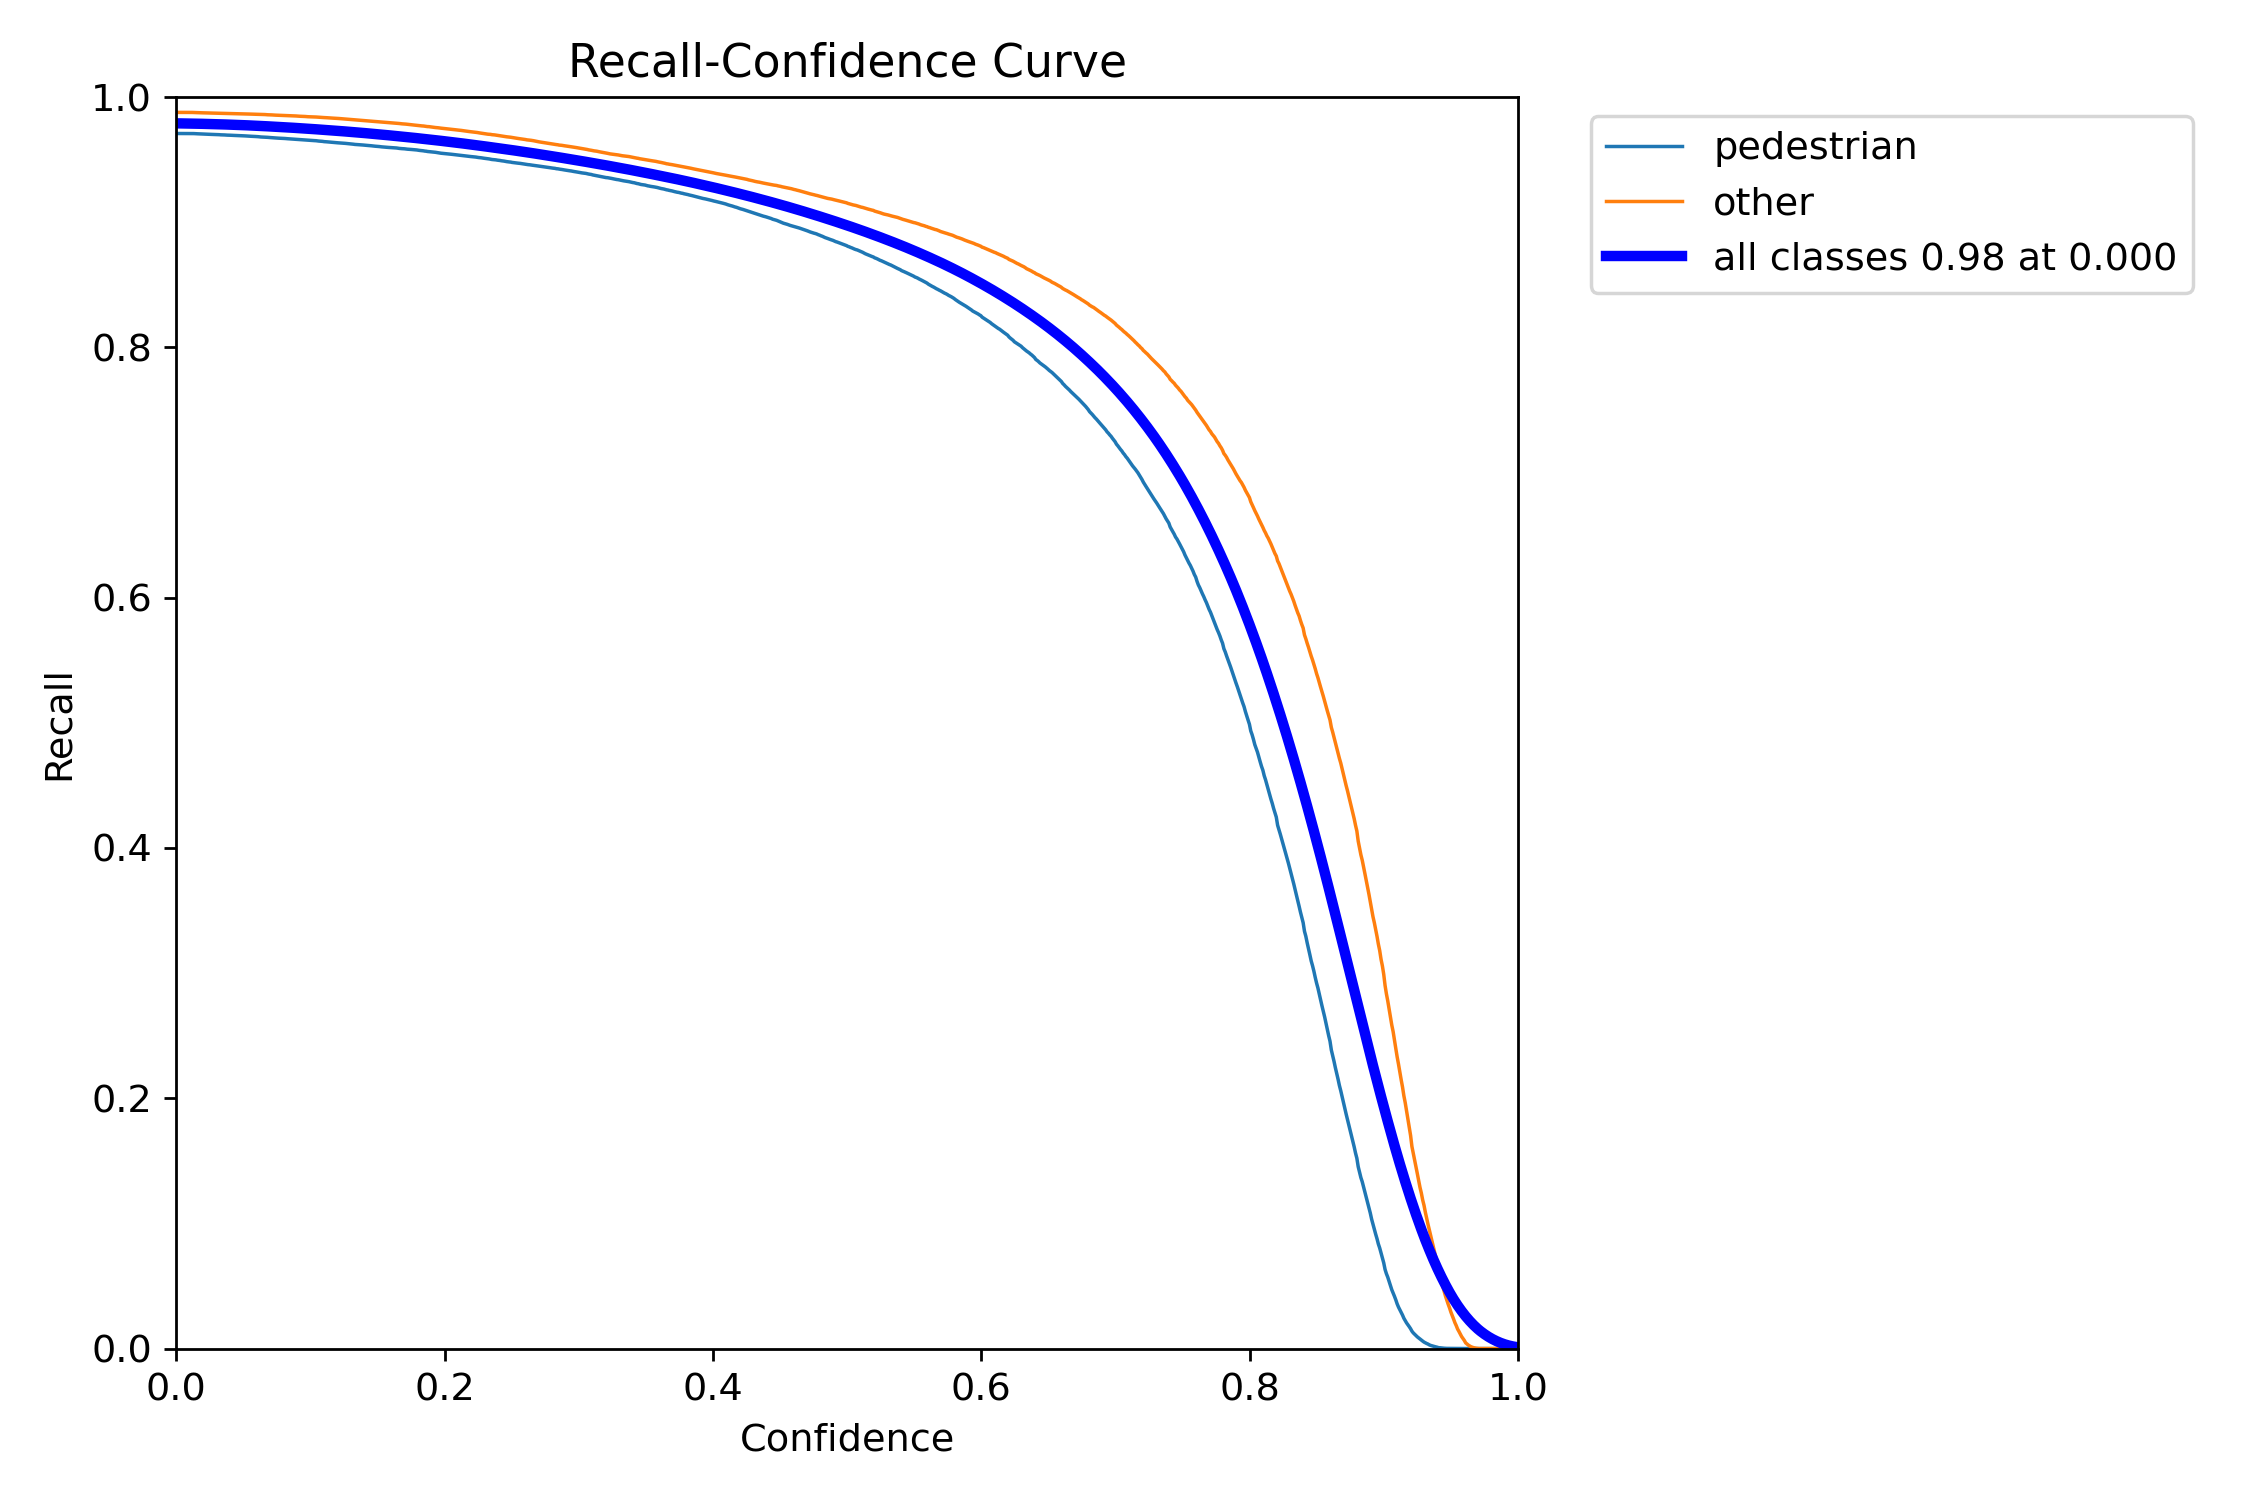

Showing: confusion_matrix_normalized.png


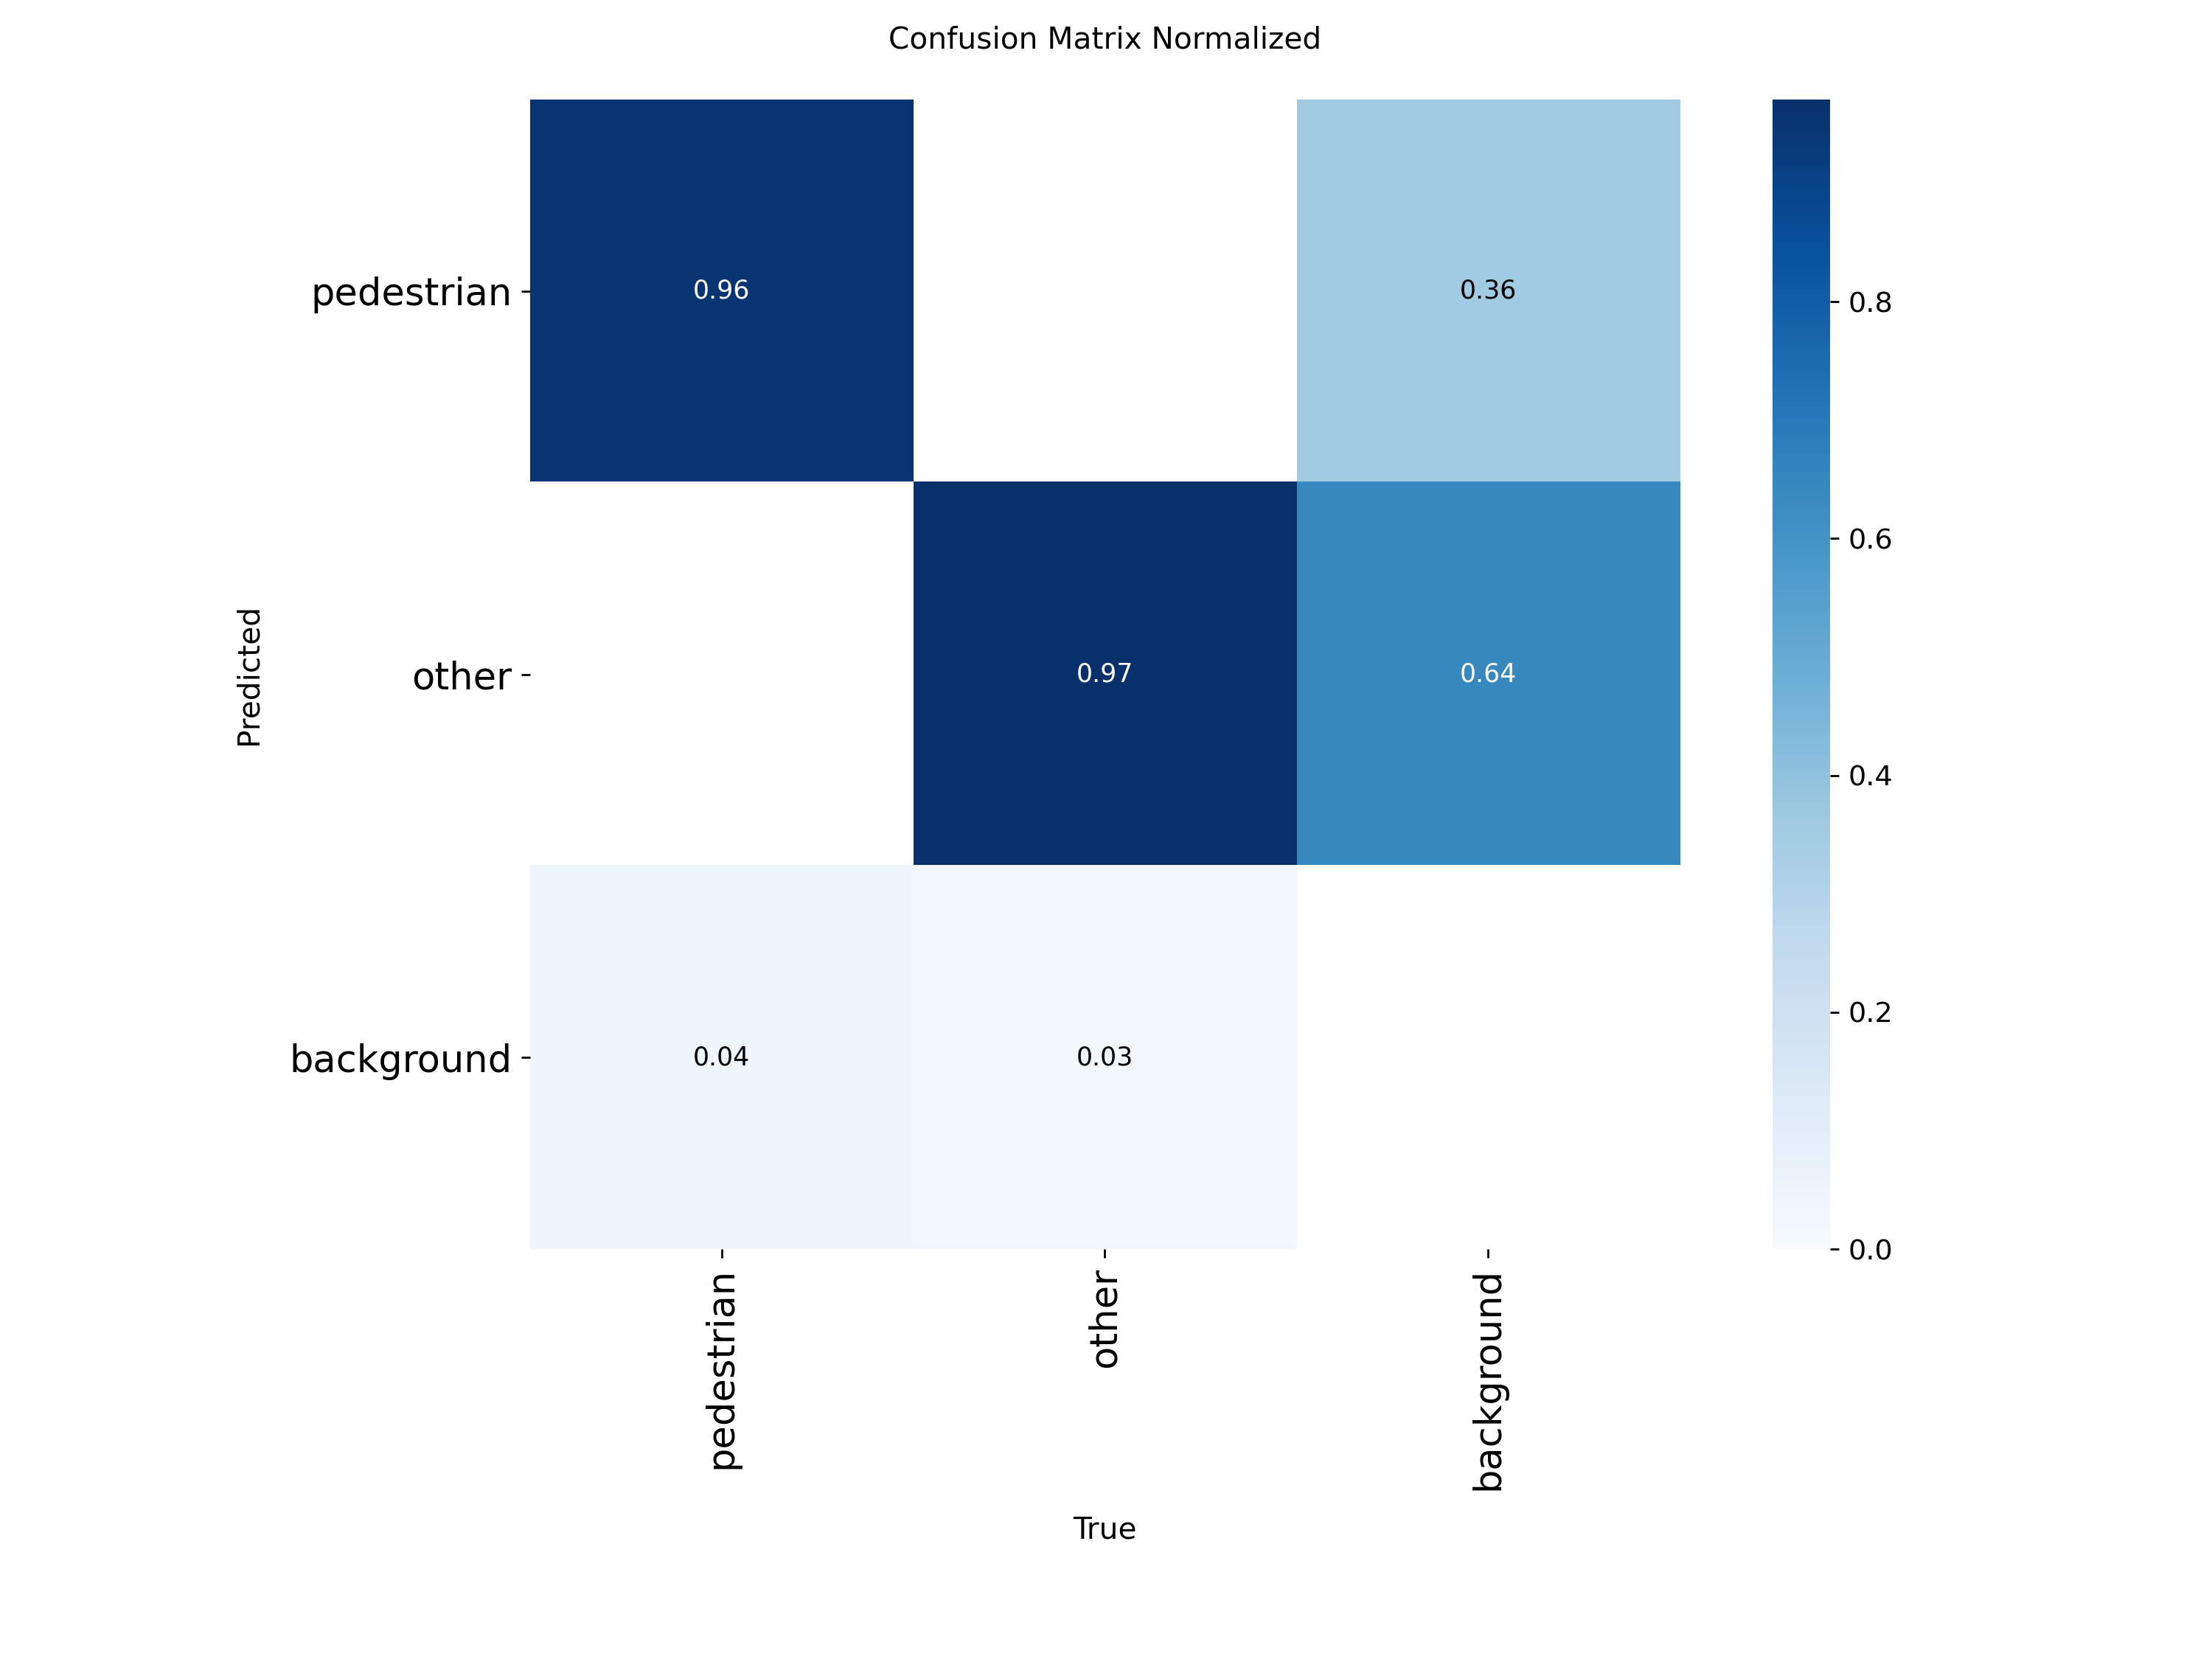

Showing: confusion_matrix.png


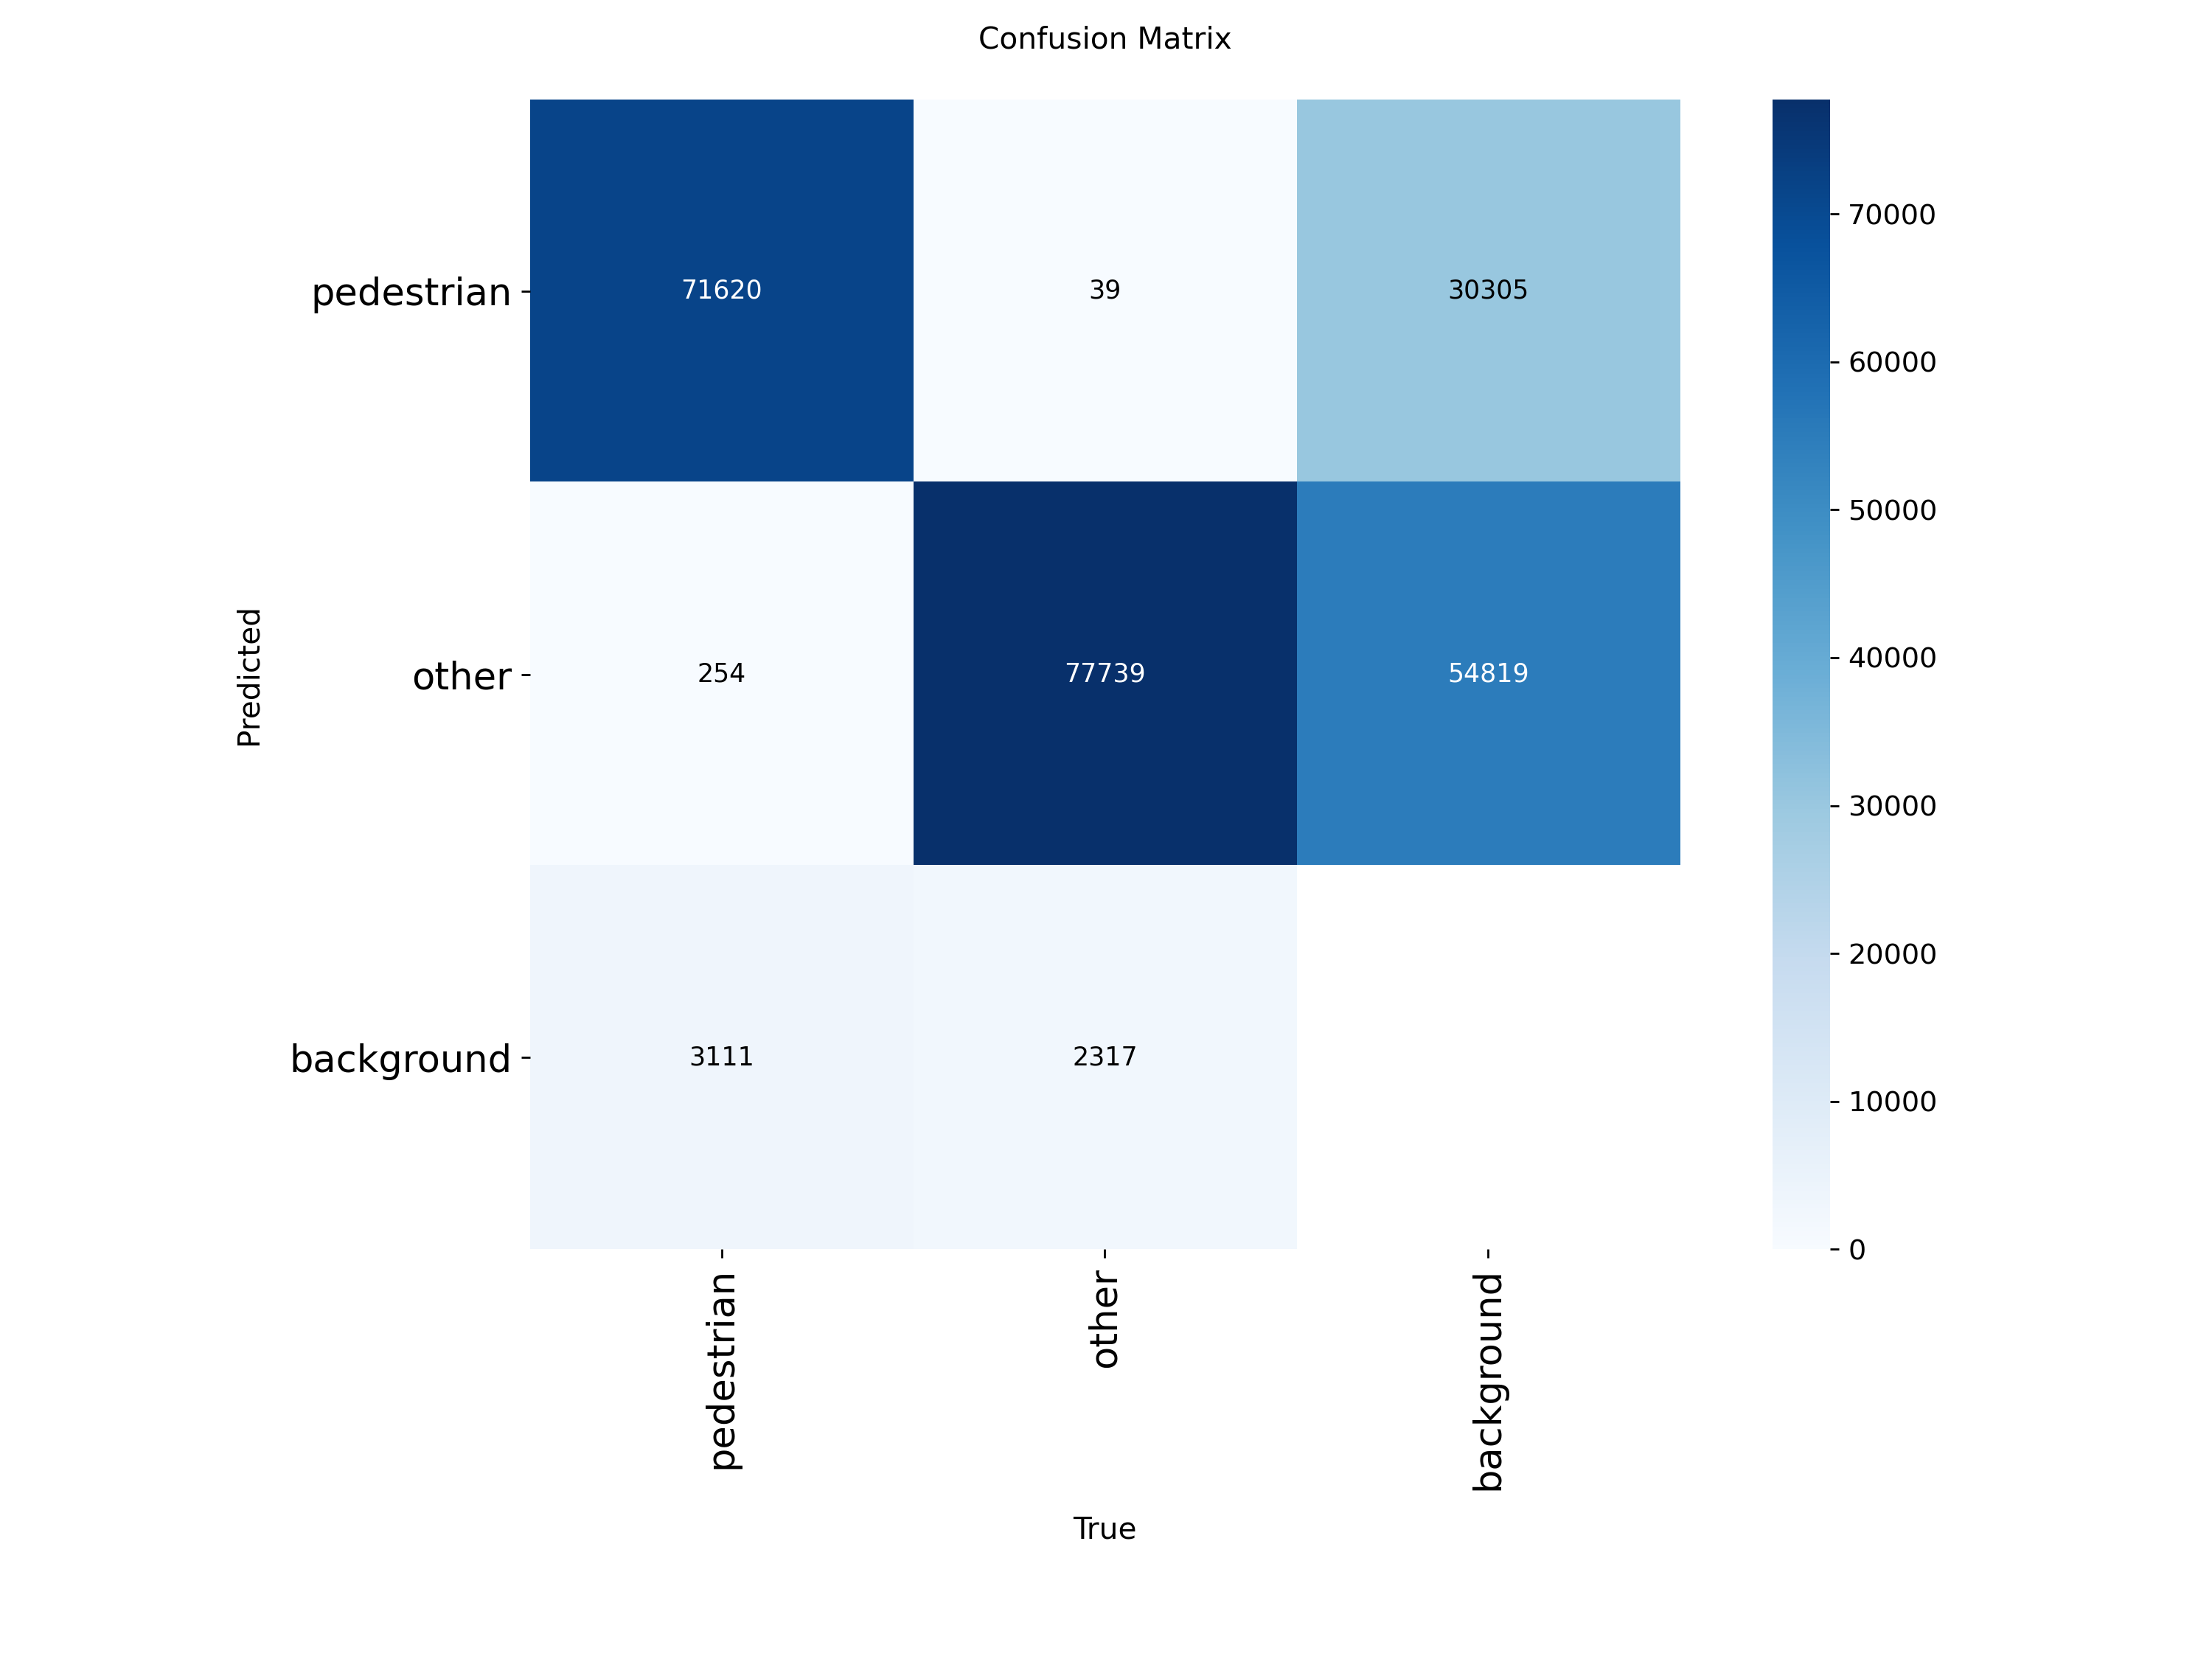

Showing: results.png


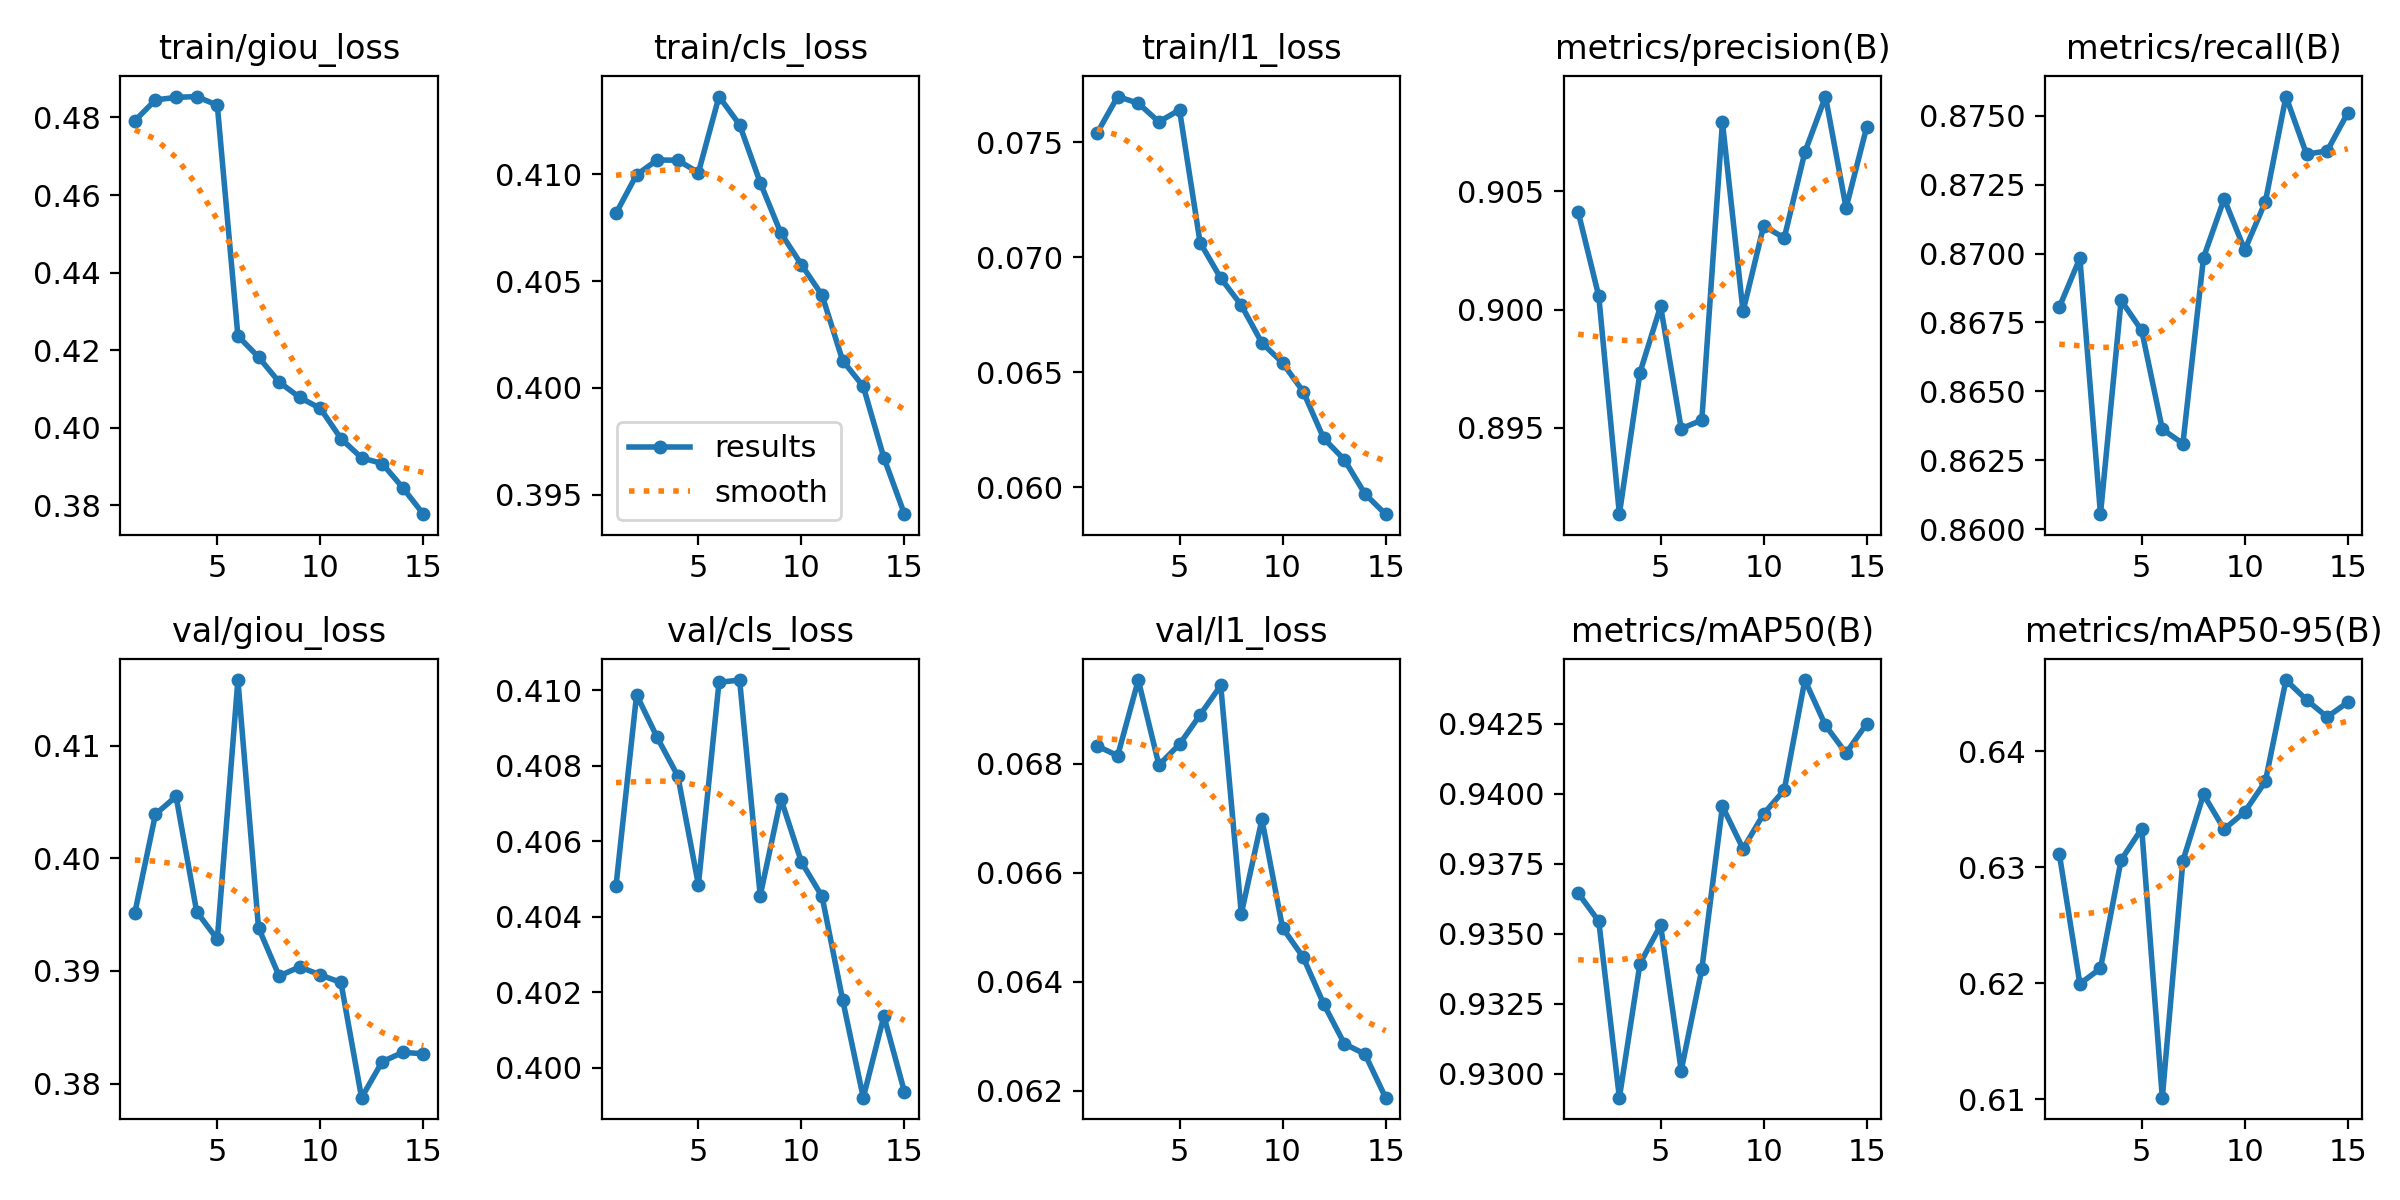

In [4]:
from IPython.display import Image, display
import os

for file in os.listdir(RUN_DIR):
    if file.endswith(".png"):
        print("Showing:", file)
        display(Image(filename=os.path.join(RUN_DIR, file)))

In [6]:
import pandas as pd

csv_path = os.path.join(RUN_DIR, "results.csv")
df = pd.read_csv(csv_path)

df.head()

,epoch,time,train/giou_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/giou_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
0,1,334.883,0.47918,0.40817,0.07540,0.90412,0.86805,0.93645,0.63119,0.39518,0.40481,0.06833,0.000555,0.000555,0.000555
1,2,651.175,0.48453,0.40998,0.07699,0.90056,0.86983,0.93544,0.61996,0.40391,0.40988,0.06815,0.001037,0.001037,0.001037
2,3,961.378,0.48519,0.41067,0.07670,0.89136,0.86055,0.92914,0.62129,0.40549,0.40875,0.06954,0.001446,0.001446,0.001446
3,4,1267.440,0.48540,0.41066,0.07589,0.89734,0.86830,0.93393,0.63063,0.39525,0.40773,0.06798,0.001337,0.001337,0.001337
4,5,1573.470,0.48317,0.41008,0.07641,0.90014,0.86721,0.93530,0.63335,0.39281,0.40485,0.06836,0.001227,0.001227,0.001227


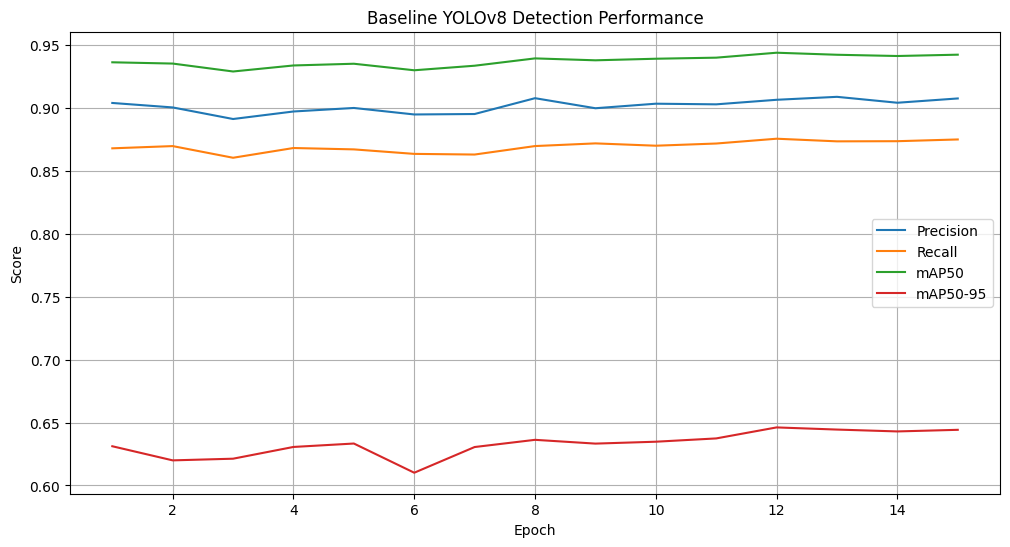

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Baseline YOLOv8 Detection Performance")
plt.legend()
plt.grid(True)
plt.show()